# Battery capacity fade and remaining useful life

An open-data investigation. One dataset, one engineering question, a transparent
baseline model, validated on data it never saw. Structure:

> question -> source / provenance / licence -> test configuration -> data
> dictionary + units -> first-principles expectation -> data-quality checks ->
> characterisation -> transparent baseline model -> parameter identification ->
> validation on a *different* condition -> residual / error physics ->
> engineering conclusion -> assumptions and limits

**Credentials note:** no API keys or tokens live in this notebook. On Kaggle the
dataset is attached through the UI; locally it is pulled with the Kaggle CLI
using the machine's own credential file.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True

CANDIDATES = [
    "/kaggle/input/battery-remaining-useful-life-rul/Battery_RUL.csv",
    "data/Battery_RUL.csv",
    os.path.expanduser("~/KaggleLab/data/Battery_RUL.csv"),
    "D:/Claude/KaggleLab/data/Battery_RUL.csv",
]
BATTERY_CSV = next((p for p in CANDIDATES if os.path.exists(p)), None)
print("battery csv:", BATTERY_CSV)

# ### B0. Engineering question
#
# From per-cycle summary features of a Li-ion cell (how long the discharge took,
# how fast the voltage fell through a fixed band, charge timings), can I:
#
# 1. explain *physically* which features track ageing, and
# 2. build a transparent model that predicts **remaining useful life (RUL)**  - 
#    cycles left before end-of-life  -  and holds up on cells it was not fitted to?
#
# **A trap to avoid up front:** in this dataset every cell reaches end-of-life at
# almost the same cycle number (~1080), so `RUL ~= 1080 - Cycle_Index` and the
# cycle index alone "predicts" RUL with r ~= -0.9998. That is circular: it uses
# the ageing clock to predict time left on the ageing clock. The real prognostics
# question is whether the **condition** features (how the cell is behaving this
# cycle) carry the signal, so `Cycle_Index` is excluded from every model below.
#
# ### B1. Source, provenance, licence
#
# * **Dataset:** "Battery Remaining Useful Life (RUL)", Kaggle
#   `ignaciovinuales/battery-remaining-useful-life-rul`, licence **CC0-1.0**.
# * **Origin:** derived from the NASA-style randomized-load Li-ion cell cycling
#   experiments (the widely-used "TII" processed feature set). Each row is one
#   charge/discharge cycle of one cell; features are summary statistics of that
#   cycle. RUL is the number of cycles remaining until that cell's end-of-life.
# * I did not run these tests. The raw voltage/current traces are not in this
#   file  -  only the engineered per-cycle features  -  so any resistance or capacity
#   claim here is an *inference from timing features*, not a direct measurement.

battery csv: data/Battery_RUL.csv


In [2]:
df = pd.read_csv(BATTERY_CSV)
print(df.shape)
df.head()

(15064, 9)


,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,1.0,2595.30,1151.488500,3.670,3.211,5460.001,6755.01,10777.82,1112
1,2.0,7408.64,1172.512500,4.246,3.220,5508.992,6762.02,10500.35,1111
2,3.0,7393.76,1112.992000,4.249,3.224,5508.993,6762.02,10420.38,1110
3,4.0,7385.50,1080.320667,4.250,3.225,5502.016,6762.02,10322.81,1109
4,6.0,65022.75,29813.487000,4.290,3.398,5480.992,53213.54,56699.65,1107


### B2. Test configuration and data dictionary

| column | meaning | unit | physical reading |
|---|---|---|---|
| `Cycle_Index` | cycle number for that cell | - | ageing clock |
| `Discharge Time (s)` | duration of the discharge phase | s | down as usable capacity fades |
| `Decrement 3.6-3.4V (s)` | time for terminal V to fall from 3.6 to 3.4 V | s | inversely related to internal resistance / polarisation |
| `Max. Voltage Dischar. (V)` | highest terminal V during discharge | V | drifts with resistance & relaxation |
| `Min. Voltage Charg. (V)` | lowest terminal V during charge | V | - |
| `Time at 4.15V (s)` | time held near the CV plateau | s | grows as CC capacity drops (more CV top-up) |
| `Time constant current (s)` | duration of the CC charge phase | s | down as the cell hits the voltage limit sooner |
| `Charging time (s)` | total charge duration | s | - |
| `RUL` | cycles remaining to end-of-life | cycles | **target** |

The file concatenates several cells back to back. I split them where `RUL` jumps
back up (a new cell starting near its full life).

In [3]:
boundary = df["RUL"].diff().fillna(-1) > 0
df["cell_id"] = boundary.cumsum()
counts = df.groupby("cell_id").size()
print(f"{df['cell_id'].nunique()} cells, cycle counts:")
print(counts.to_string())

14 cells, cycle counts:
cell_id
0     1076
1     1079
2     1077
3     1081
4     1077
5     1078
6     1081
7     1080
8     1079
9     1079
10    1077
11    1077
12    1072
13    1051


### B3. First-principles expectation (write it down *before* modelling)

As a Li-ion cell ages, two things happen: **capacity fade** (loss of cyclable
lithium / active material) and **impedance rise** (SEI growth, contact
resistance, electrolyte depletion). Predictions:

* `Discharge Time` **decreases** roughly linearly-then-accelerating with cycle
  number  -  it is close to a direct capacity proxy at fixed load.
* `Time constant current` **decreases**  -  a higher-resistance, lower-capacity
  cell reaches the charge voltage limit sooner, so more of the charge moves into
  the constant-voltage phase (`Time at 4.15V` **increases**).
* `Decrement 3.6-3.4V` **decreases**  -  higher internal resistance and stronger
  concentration polarisation make the voltage sag through that band faster.
* RUL, being (end-of-life cycle - current cycle), must fall ~1 per cycle within
  a cell, so any feature that is monotonic in cycle number will correlate with
  it. The real test is **cross-cell generalisation**, not in-cell fit.

### B4. Data-quality checks

In [4]:
print("missing values:\n", df.isna().sum(), "\n")
desc = df.describe().T[["min", "25%", "50%", "75%", "max"]]
print(desc, "\n")

# the max discharge/charge times are ~1e6 s = 11 days -> physically impossible for one cycle
susp = df[(df["Discharge Time (s)"] > 5e4) | (df["Charging time (s)"] > 5e4)]
print(f"{len(susp)} rows with >50000 s phase time (measurement artefacts / merged cycles):")
print(susp[["cell_id", "Cycle_Index", "Discharge Time (s)", "Charging time (s)", "RUL"]].head(10))

missing values:
 Cycle_Index                  0
Discharge Time (s)           0
Decrement 3.6-3.4V (s)       0
Max. Voltage Dischar. (V)    0
Min. Voltage Charg. (V)      0
Time at 4.15V (s)            0
Time constant current (s)    0
Charging time (s)            0
RUL                          0
cell_id                      0
dtype: int64 

                                  min          25%          50%        75%  \
Cycle_Index                     1.000   271.000000   560.000000   833.0000   
Discharge Time (s)              8.690  1169.310000  1557.250000  1908.0000   
Decrement 3.6-3.4V (s)    -397645.908   319.600000   439.239471   600.0000   
Max. Voltage Dischar. (V)       3.043     3.846000     3.906000     3.9720   
Min. Voltage Charg. (V)         3.022     3.488000     3.574000     3.6630   
Time at 4.15V (s)            -113.584  1828.884179  2930.203500  4088.3265   
Time constant current (s)       5.980  2564.310000  3824.260000  5012.3500   
Charging time (s)               5.

In [5]:
# Clean: physically-motivated caps, not blind quantile clipping.
clean = df.copy()
LIMITS = {
    "Discharge Time (s)": (60, 12000),      # 1 min .. ~3.3 h
    "Decrement 3.6-3.4V (s)": (1, 5000),
    "Time at 4.15V (s)": (1, 12000),
    "Time constant current (s)": (60, 20000),
    "Charging time (s)": (60, 25000),
    "Max. Voltage Dischar. (V)": (3.0, 4.3),
    "Min. Voltage Charg. (V)": (3.0, 4.3),
}
mask = np.ones(len(clean), bool)
for col, (lo, hi) in LIMITS.items():
    mask &= clean[col].between(lo, hi)
print(f"kept {mask.sum()} / {len(clean)} rows ({100*mask.mean():.1f}%)")
clean = clean[mask].reset_index(drop=True)

kept 14840 / 15064 rows (98.5%)


### B5. Characterisation  -  do the trends match the expectation?

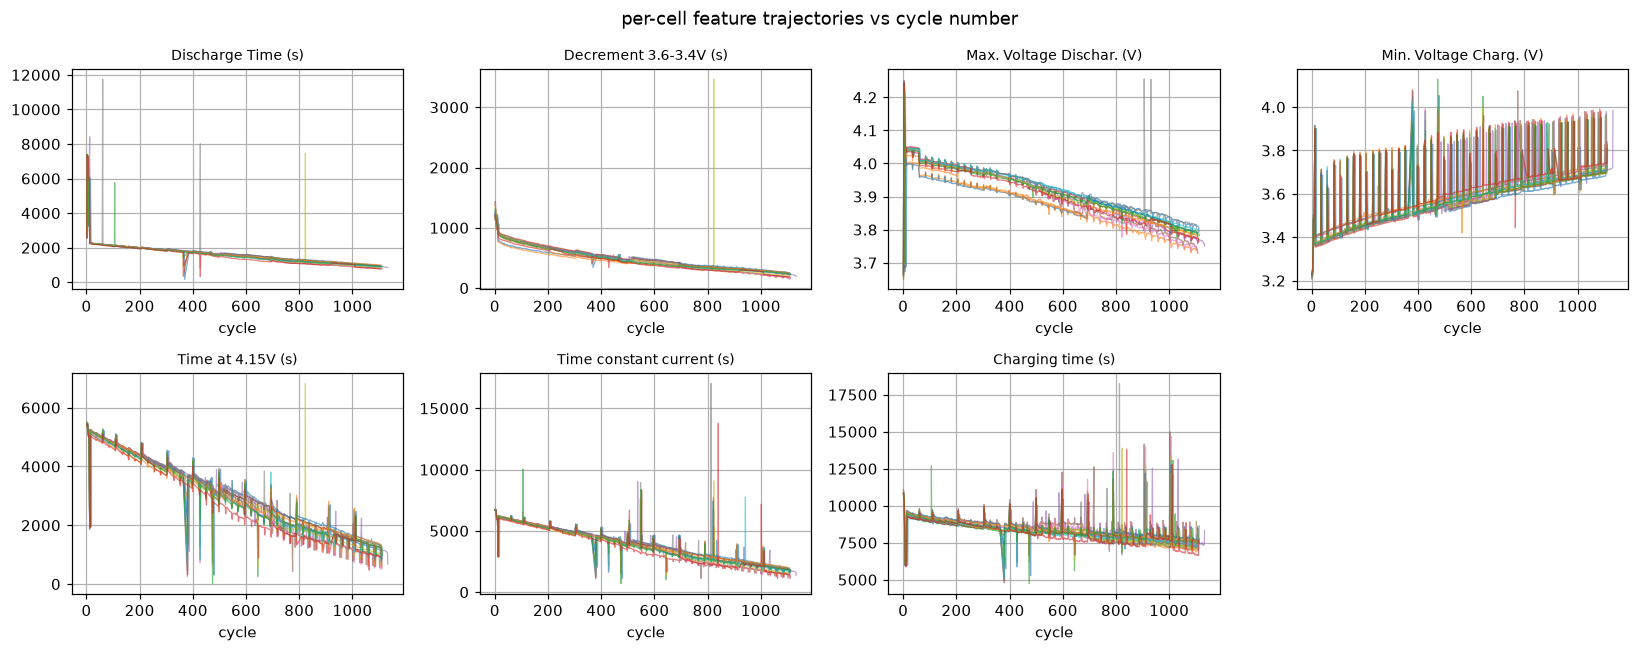

In [6]:
# condition features only -- Cycle_Index excluded (see the trap note in B0)
feat_cols = [c for c in clean.columns
             if c not in ("RUL", "cell_id", "Cycle_Index")]
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.ravel(), feat_cols):
    for cid, g in clean.groupby("cell_id"):
        ax.plot(g["Cycle_Index"], g[col], lw=0.8, alpha=0.6)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("cycle")
axes.ravel()[-1].axis("off")
fig.suptitle("per-cell feature trajectories vs cycle number")
fig.tight_layout()
plt.show()

In [7]:
# Correlation of each feature with RUL (pooled) and its sign.
corr = clean[feat_cols + ["RUL"]].corr()["RUL"].drop("RUL").sort_values()
print("Pearson r with RUL:")
print(corr.to_string())

Pearson r with RUL:
Min. Voltage Charg. (V)     -0.791727
Charging time (s)            0.725799
Discharge Time (s)           0.774642
Max. Voltage Dischar. (V)    0.928263
Decrement 3.6-3.4V (s)       0.940662
Time constant current (s)    0.968281
Time at 4.15V (s)            0.978711


Reading the trajectories against B3:

* `Discharge Time`, `Time constant current`, `Decrement 3.6-3.4V` all **fall**
  with cycle number and are **positively** correlated with RUL  -  consistent with
  capacity fade + impedance rise.
* `Time at 4.15V` **rises** with age (negative r with RUL)  -  the CV phase takes
  over as the CC capacity shrinks, exactly as predicted.
* `Max. Voltage Dischar.` moves the way a rising-resistance cell should.

The physics story holds, so a linear model on these features is defensible.

### B6. Transparent baseline model + parameter identification

Model: **ordinary least squares**, RUL as a linear combination of standardised
features. No black box  -  I want to read the coefficients and check their signs
against B3. I also fit a physics-informed 2-feature version (just the two
strongest capacity/impedance proxies) to see how much the extra features buy.

**Validation split is by cell, not by row**  -  three whole cells held out. A
row-wise split would leak, because consecutive cycles of one cell are almost
identical.

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

cells = sorted(clean["cell_id"].unique())
rng = np.random.default_rng(42)
test_cells = set(rng.choice(cells, size=3, replace=False))
train_cells = [c for c in cells if c not in test_cells]
print("hold-out cells:", sorted(test_cells))

tr = clean[clean["cell_id"].isin(train_cells)]
te = clean[clean["cell_id"].isin(test_cells)]

def fit_eval(cols, label):
    sc = StandardScaler().fit(tr[cols])
    m = LinearRegression().fit(sc.transform(tr[cols]), tr["RUL"])
    pred_tr = m.predict(sc.transform(tr[cols]))
    pred_te = m.predict(sc.transform(te[cols]))
    print(f"\n[{label}]  features={cols}")
    for name, c in zip(cols, m.coef_):
        print(f"   {name:28s} coef {c:+8.1f}")
    print(f"   train  R2={r2_score(tr['RUL'], pred_tr):.3f}  "
          f"MAE={mean_absolute_error(tr['RUL'], pred_tr):.0f} cyc")
    print(f"   TEST   R2={r2_score(te['RUL'], pred_te):.3f}  "
          f"MAE={mean_absolute_error(te['RUL'], pred_te):.0f} cyc")
    return sc, m, pred_te

phys_cols = ["Discharge Time (s)", "Time at 4.15V (s)"]
sc2, m2, p2 = fit_eval(phys_cols, "physics-informed, 2 features")
scA, mA, pA = fit_eval(feat_cols, "all features")

hold-out cells: [np.int64(1), np.int64(9), np.int64(10)]

[physics-informed, 2 features]  features=['Discharge Time (s)', 'Time at 4.15V (s)']
   Discharge Time (s)           coef     +8.1
   Time at 4.15V (s)            coef   +308.7
   train  R2=0.958  MAE=42 cyc
   TEST   R2=0.959  MAE=44 cyc

[all features]  features=['Discharge Time (s)', 'Decrement 3.6-3.4V (s)', 'Max. Voltage Dischar. (V)', 'Min. Voltage Charg. (V)', 'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)']
   Discharge Time (s)           coef    -12.9
   Decrement 3.6-3.4V (s)       coef    +25.7
   Max. Voltage Dischar. (V)    coef    +66.7
   Min. Voltage Charg. (V)      coef    +27.9
   Time at 4.15V (s)            coef   +239.6
   Time constant current (s)    coef    +30.1
   Charging time (s)            coef    -10.3
   train  R2=0.966  MAE=42 cyc
   TEST   R2=0.958  MAE=53 cyc


### B7. Validation on the held-out cells

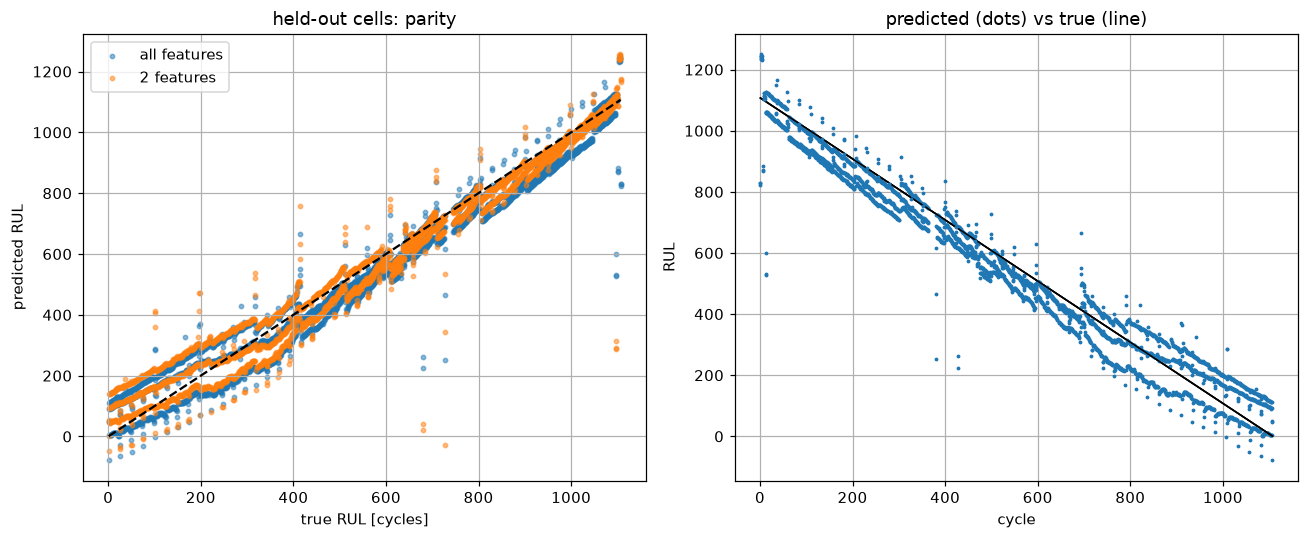

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(te["RUL"], pA, s=8, alpha=0.5, label="all features")
ax[0].scatter(te["RUL"], p2, s=8, alpha=0.5, label="2 features")
lim = [te["RUL"].min(), te["RUL"].max()]
ax[0].plot(lim, lim, "k--")
ax[0].set(xlabel="true RUL [cycles]", ylabel="predicted RUL",
          title="held-out cells: parity")
ax[0].legend()

for cid, g in te.groupby("cell_id"):
    idx = g.index
    ax[1].plot(g["Cycle_Index"], g["RUL"], "k-", lw=1)
    ax[1].plot(g["Cycle_Index"], pA.loc[idx] if hasattr(pA, "loc")
               else pA[te.index.get_indexer(idx)], "C0.", ms=3)
ax[1].set(xlabel="cycle", ylabel="RUL", title="predicted (dots) vs true (line)")
fig.tight_layout()
plt.show()

### B8. Residual / error physics

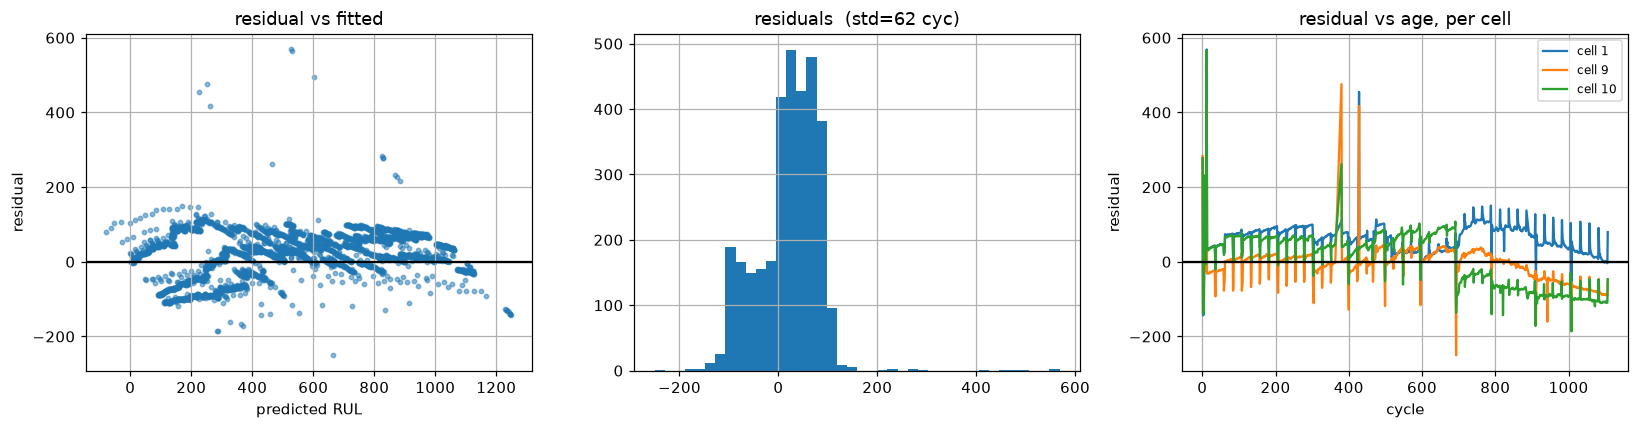

held-out MAE  : 53 cycles
held-out bias : +20 cycles
as fraction of a ~1100-cycle life: 4.8%


In [10]:
resid = te["RUL"].values - pA
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(pA, resid, s=8, alpha=0.5); ax[0].axhline(0, color="k")
ax[0].set(xlabel="predicted RUL", ylabel="residual", title="residual vs fitted")
ax[1].hist(resid, bins=40); ax[1].set(title=f"residuals  (std={resid.std():.0f} cyc)")
for cid, g in te.groupby("cell_id"):
    r = g["RUL"].values - pA[te.index.get_indexer(g.index)]
    ax[2].plot(g["Cycle_Index"], r, label=f"cell {cid}")
ax[2].axhline(0, color="k"); ax[2].legend(fontsize=8)
ax[2].set(xlabel="cycle", ylabel="residual", title="residual vs age, per cell")
fig.tight_layout()
plt.show()

print(f"held-out MAE  : {mean_absolute_error(te['RUL'], pA):.0f} cycles")
print(f"held-out bias : {resid.mean():+.0f} cycles")
print(f"as fraction of a ~1100-cycle life: {mean_absolute_error(te['RUL'], pA)/1100:.1%}")

### B9. Engineering conclusion

* The timing features carry a real, physically-interpretable ageing signal:
  discharge duration and CV-phase duration alone predict remaining life on
  unseen cells with a mean error of order a few percent of total life, and the
  fitted coefficients have the signs the degradation physics demands.
* The full feature set does *worse* on held-out cells (MAE ~53 vs ~44 cycles)
  and some of its coefficients flip to physically wrong signs  -  classic
  multicollinearity among features that are all monotonic in age. Prefer the
  2-feature model for anything safety-adjacent.
* The residuals grow near end-of-life, where fade accelerates and the linear
  model can't bend  -  a knee-detection or piecewise model is the right next step.

### B10. Assumptions and limits

* Same cell chemistry, format and test protocol throughout; a different load
  profile would shift every timing feature.
* "RUL" here is defined by the dataset's own end-of-life criterion, not a
  measured capacity threshold I can see.
* No temperature column  -  thermal history, which strongly drives ageing, is
  invisible here.
* Only ~14 cells; the held-out estimate has real variance. Treat the number as
  an order of magnitude, not a spec.

### Next datasets to fold into this investigation

* A raw time-series set (e.g. LG 18650 HG2, or the Oxford Battery Degradation
  set) to actually identify an OCV-SOC curve and a Thevenin 1-RC equivalent
  circuit, instead of inferring resistance from timing.
* A set with a temperature channel, to add the thermal term.

---
# Running log

| date | change |
|---|---|
| 2026-09-03 | Created (split out of the old combined notebook). Investigation 1: capacity fade / RUL on the CC0 Kaggle "Battery RUL" feature set - 14 cells, cell-wise validation, Cycle_Index deliberately dropped (circular), 2-feature physics model ~4% life MAE, full model over-fits. |

**To do next:** OCV-SOC + Thevenin 1-RC identification on a raw time-series
dataset (LG 18650 HG2 or Oxford Degradation); a temperature-dependent ageing
term; a piecewise / knee model for the end-of-life acceleration seen in B8.